In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

log_dir = "log/ml_100k/" # "log/ml_1m/" or "log/beauty_2m/"

# -------------------------------------------------------
# Load all experiment results
# -------------------------------------------------------

rows = []

for f in os.listdir(log_dir):
    if f.endswith(".pkl"):
        path = os.path.join(log_dir, f)
        r = torch.load(path, map_location="cpu")

        rows.append({
            "file": f,
            "L": r["config"]["num_layers"],
            "k": r["config"]["num_samples_per_user"],

            "total_time": r["timing"]["total_training_time_seconds"],
            "prop_time": r["timing"]["propagation_time_seconds"],
            "bpr_time": r["timing"]["bpr_objective_time_seconds"],
            "forward_time": r["timing"]["bprforward_total_time_seconds"],
            "backward_time": r["timing"]["backward_step_time_seconds"],
            "eval_time": r["timing"]["evaluation_time_seconds"],

            "test_precision": r["test_result"]["test_topks"]["test_p"],
            "test_recall": r["test_result"]["test_topks"]["test_r"]
        })

df = pd.DataFrame(rows)
df = df.sort_values(["L", "k"])

print("Loaded experiments:", len(df))
display(df.head())

Loaded experiments: 17


,file,L,k,total_time,prop_time,bpr_time,forward_time,backward_time,eval_time,test_precision,test_recall
2,result_movielens100k_2layers_1sample_allusers.pkl,2,1,33.116417,0.110662,0.172036,0.282699,0.735589,31.963489,0.096288,0.053851
5,result_movielens100k_2layers_5sample_allusers.pkl,2,5,37.302663,0.396886,0.618597,1.015483,2.940932,33.041093,0.120785,0.102313
0,result_movielens100k_2layers_10sample_allusers...,2,10,41.157485,0.746505,1.217300,1.963805,5.781047,32.903570,0.167550,0.126943
1,result_movielens100k_2layers_15sample_allusers...,2,15,37.954980,1.009567,1.582628,2.592196,7.877420,26.885292,0.172959,0.132152
3,result_movielens100k_2layers_20sample_allusers...,2,20,43.961169,1.327999,2.122278,3.450276,10.548577,29.094029,0.175716,0.134092


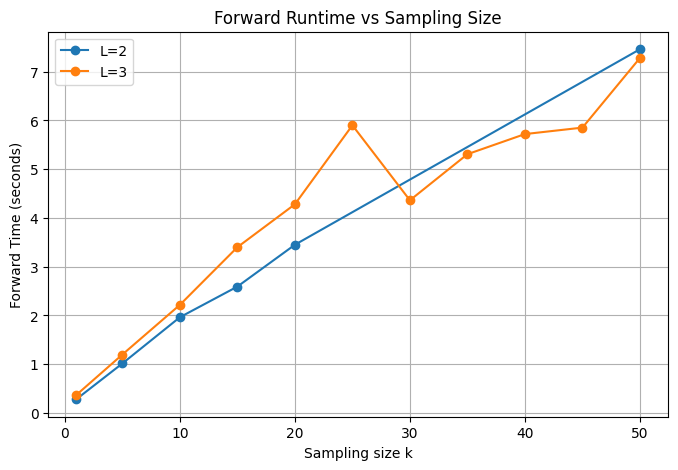

In [2]:
# -------------------------------------------------------
# Runtime vs sampling size k
# -------------------------------------------------------

plt.figure(figsize=(8,5))

for L in sorted(df["L"].unique()):
    subset = df[df["L"] == L]
    plt.plot(subset["k"], subset["forward_time"], marker="o", label=f"L={L}")

plt.xlabel("Sampling size k")
plt.ylabel("Forward Time (seconds)")
plt.title("Forward Runtime vs Sampling Size")
plt.legend()
plt.grid(True)
plt.show()

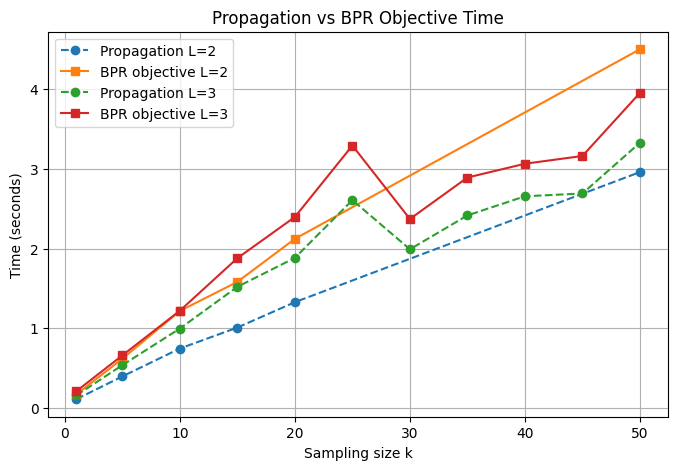

In [3]:
# -------------------------------------------------------
# Propagation vs BPR objective time
# -------------------------------------------------------

plt.figure(figsize=(8,5))

for L in sorted(df["L"].unique()):
    subset = df[df["L"] == L]

    plt.plot(subset["k"], subset["prop_time"], marker="o", linestyle="--",
             label=f"Propagation L={L}")

    plt.plot(subset["k"], subset["bpr_time"], marker="s",
             label=f"BPR objective L={L}")

plt.xlabel("Sampling size k")
plt.ylabel("Time (seconds)")
plt.title("Propagation vs BPR Objective Time")
plt.legend()
plt.grid(True)
plt.show()

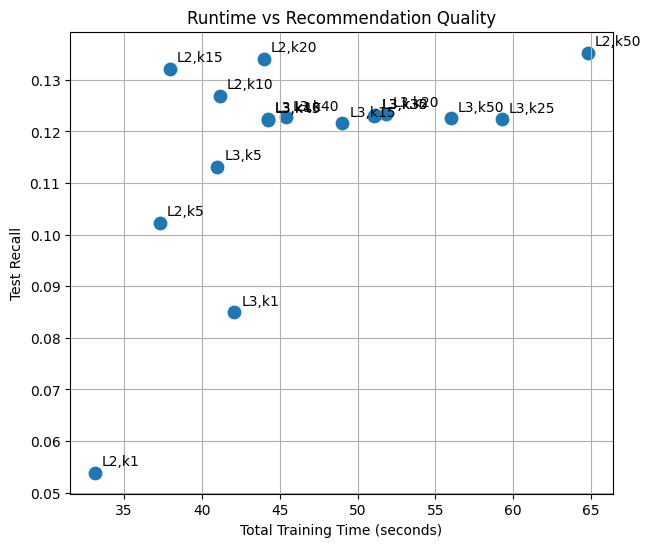

In [4]:
# -------------------------------------------------------
# Runtime vs Recall trade-off
# -------------------------------------------------------

plt.figure(figsize=(7,6))

plt.scatter(df["total_time"], df["test_recall"], s=80)

for i in range(len(df)):
    label = f"L{df.iloc[i]['L']},k{df.iloc[i]['k']}"
    plt.annotate(label,
                 (df.iloc[i]["total_time"], df.iloc[i]["test_recall"]),
                 xytext=(5,5),
                 textcoords="offset points")

plt.xlabel("Total Training Time (seconds)")
plt.ylabel("Test Recall")
plt.title("Runtime vs Recommendation Quality")
plt.grid(True)
plt.show()

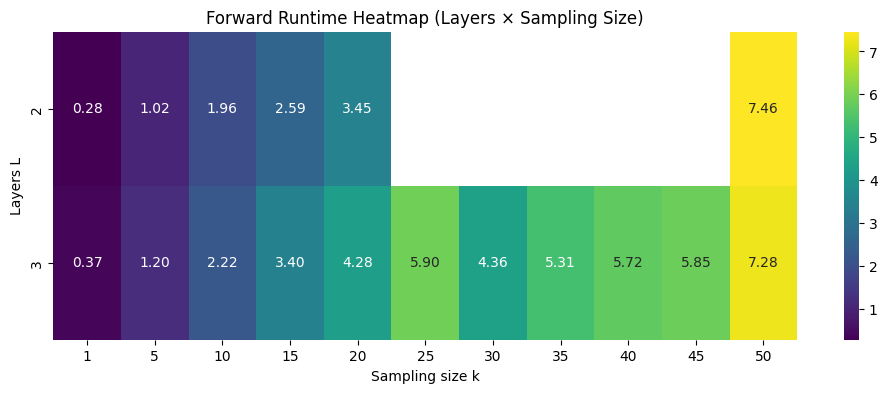

In [5]:
# -------------------------------------------------------
# Heatmap: runtime for (L × k)
# -------------------------------------------------------

pivot = df.pivot(index="L", columns="k", values="forward_time")

plt.figure(figsize=(12,4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")

plt.title("Forward Runtime Heatmap (Layers × Sampling Size)")
plt.xlabel("Sampling size k")
plt.ylabel("Layers L")
plt.show()

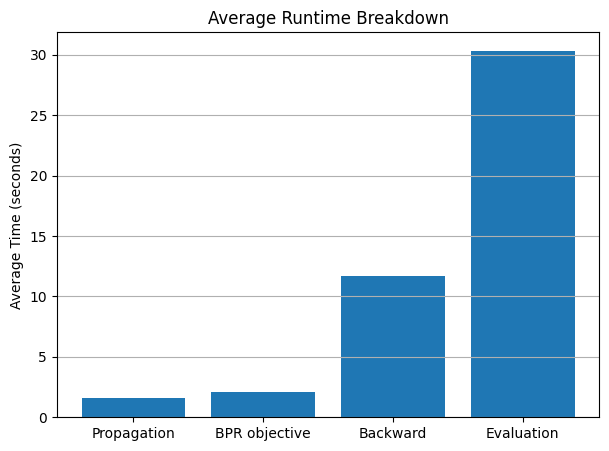

In [6]:
# -------------------------------------------------------
# Total runtime breakdown
# -------------------------------------------------------

mean_times = [
    df["prop_time"].mean(),
    df["bpr_time"].mean(),
    df["backward_time"].mean(),
    df["eval_time"].mean()
]

labels = [
    "Propagation",
    "BPR objective",
    "Backward",
    "Evaluation"
]

plt.figure(figsize=(7,5))
plt.bar(labels, mean_times)

plt.ylabel("Average Time (seconds)")
plt.title("Average Runtime Breakdown")
plt.grid(axis="y")
plt.show()